In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Tekrarlanabilirlik için
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Veri yükleme
df = pd.read_csv('AirPassengers.csv')
if '#Passengers' in df.columns:
    df.rename(columns={'#Passengers': 'Passengers'}, inplace=True)

df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Değerleri al
values = df['Passengers'].values.astype('float32').reshape(-1, 1)

# 0-1 aralığına ölçekle
scaler = MinMaxScaler(feature_range=(0, 1))
values_scaled = scaler.fit_transform(values)

print(f"Veri seti: {len(values)} gözlem")
print(f"Tarih aralığı: {df.index.min()} - {df.index.max()}")

Veri seti: 144 gözlem
Tarih aralığı: 1949-01-01 00:00:00 - 1960-12-01 00:00:00


In [22]:
def create_dataset(sequence, look_back=1):
    """
    Zaman serisini gözetimli öğrenme formatına dönüştürür.
    
    Parametreler:
        sequence: Ölçeklenmiş zaman serisi (2D array)
        look_back: Kaç geçmiş gözleme bakılacağı
    
    Döndürür:
        X: Giriş matrisi (n_samples, look_back)
        y: Hedef vektörü (n_samples,)
    """
    X, y = [], []
    for i in range(len(sequence) - look_back):
        X.append(sequence[i:(i + look_back), 0])
        y.append(sequence[i + look_back, 0])
    return np.array(X), np.array(y)

# look_back = 12 seçiyoruz (1 yıllık örüntü)
look_back = 12
X_all, y_all = create_dataset(values_scaled, look_back)

print(f"X boyutu: {X_all.shape}")  # (132, 12)
print(f"y boyutu: {y_all.shape}")  # (132,)

# Eğitim / Test ayrımı
train_size = int(len(X_all) * 0.8)
X_train, X_test = X_all[:train_size], X_all[train_size:]
y_train, y_test = y_all[:train_size], y_all[train_size:]

# LSTM için 3D format: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"\nEğitim: {X_train.shape[0]} gözlem")
print(f"Test: {X_test.shape[0]} gözlem")

X boyutu: (132, 12)
y boyutu: (132,)

Eğitim: 105 gözlem
Test: 27 gözlem


In [23]:
def build_lstm_model(look_back, units=50, dropout_rate=0.2):
    """LSTM modeli oluşturur."""
    model = Sequential([
        LSTM(units, input_shape=(look_back, 1), return_sequences=True),
        Dropout(dropout_rate),
        LSTM(units),
        Dropout(dropout_rate),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Model oluştur
model = build_lstm_model(look_back, units=50, dropout_rate=0.2)
model.summary()

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# Eğitim
print("\nModel eğitiliyor...")
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print(f"Eğitim {len(history.history['loss'])} epoch sürdü.")

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 12, 50)            10400     
                                                                 
 dropout_6 (Dropout)         (None, 12, 50)            0         
                                                                 
 lstm_7 (LSTM)               (None, 50)                20200     
                                                                 
 dropout_7 (Dropout)         (None, 50)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 51        
                                                                 
Total params: 30651 (119.73 KB)
Trainable params: 30651 (119.73 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

Model eğitiliyo

In [24]:
# Tahminler
train_pred = model.predict(X_train, verbose=0)
test_pred = model.predict(X_test, verbose=0)

# Orijinal ölçeğe dönüştür
train_pred_inv = scaler.inverse_transform(train_pred)
test_pred_inv = scaler.inverse_transform(test_pred)
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Performans metrikleri
def calc_metrics(y_true, y_pred, name=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{name}:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE:  {mae:.2f}")
    print(f"  MAPE: {mape:.2f}%")

calc_metrics(y_train_inv, train_pred_inv, "LSTM Eğitim")
calc_metrics(y_test_inv, test_pred_inv, "LSTM Test")


LSTM Eğitim:
  RMSE: 17.43
  MAE:  14.04
  MAPE: 5.79%

LSTM Test:
  RMSE: 38.02
  MAE:  32.46
  MAPE: 7.56%


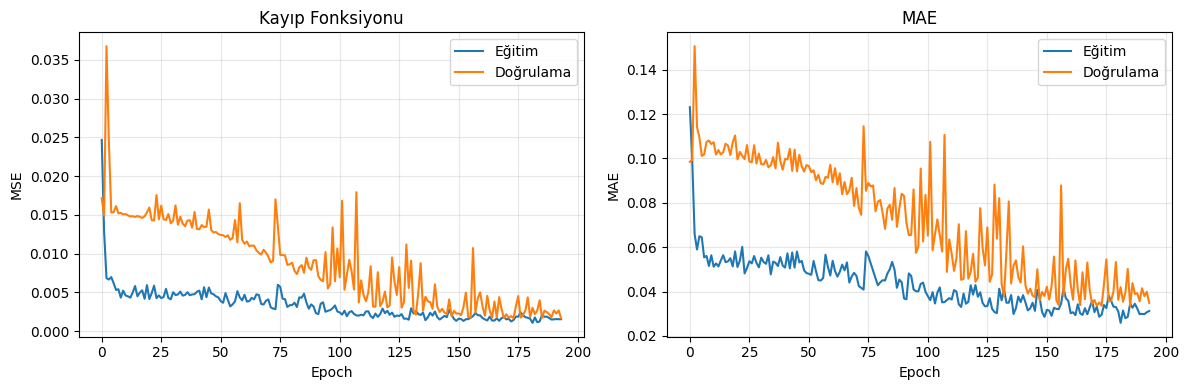

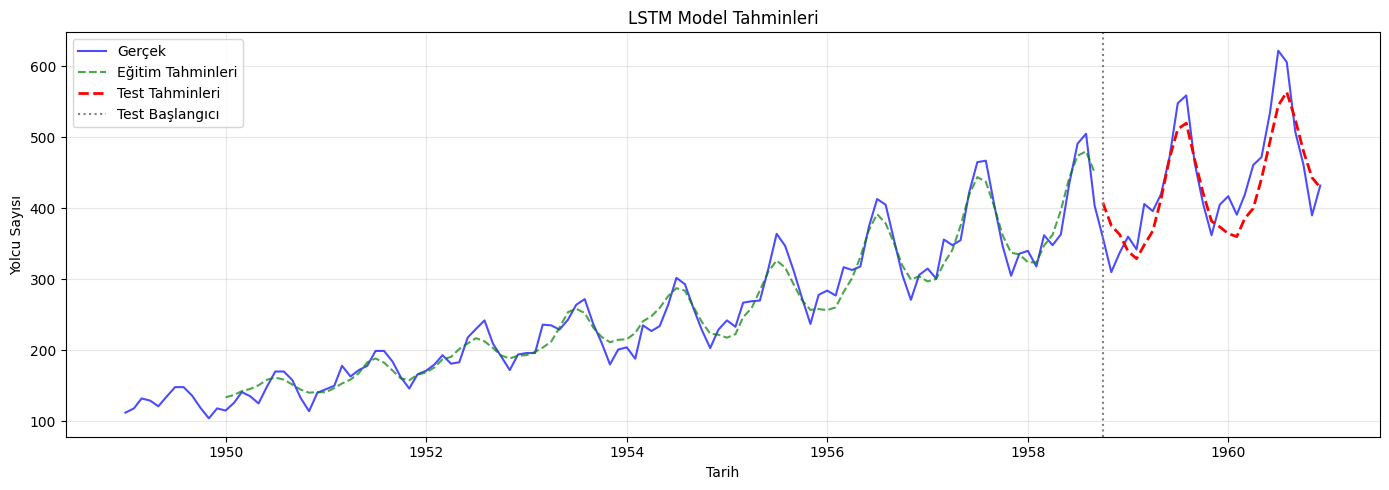

In [25]:
# Eğitim süreci
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Eğitim')
axes[0].plot(history.history['val_loss'], label='Doğrulama')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_title('Kayıp Fonksiyonu')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Eğitim')
axes[1].plot(history.history['val_mae'], label='Doğrulama')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tahmin grafiği
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Passengers'], 'b-', label='Gerçek', alpha=0.7)

train_dates = df.index[look_back:look_back + len(y_train_inv)]
test_dates = df.index[look_back + len(y_train_inv):]

plt.plot(train_dates, train_pred_inv, 'g--', label='Eğitim Tahminleri', alpha=0.7)
plt.plot(test_dates, test_pred_inv, 'r--', label='Test Tahminleri', linewidth=2)
plt.axvline(x=test_dates[0], color='gray', linestyle=':', label='Test Başlangıcı')

plt.xlabel('Tarih')
plt.ylabel('Yolcu Sayısı')
plt.title('LSTM Model Tahminleri')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()